In [1]:
!pip install wordcloud unidecode nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from tqdm import tqdm
import re
from unidecode import unidecode
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix


tqdm.pandas()

In [47]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv')
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [49]:
def preprocess(text):
    text = text.lower()

    # extraer y conservar partes de la url si existe
    url_text = ''
    m = re.search(r"(https?://\S+|www\.\S+)", text)
    if m:
        u = m.group(0)
        u = re.sub(r"https?://", '', u)
        u = re.sub(r"^www\.", '', u)
        parts = re.split(r"[\./\?=&#_-]+", u)
        url_text = ' '.join([p for p in parts if p])

    # Cotempla las posibles formas en las que puede aparecer una url
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    # Eliminación de las menciones
    text = re.sub(r'@\w+', '', text)
    # Eliminación de hashtags
    text = re.sub(r'#\w+', '', text)
    # Solo texto
    text = re.sub(r'[^\w\s]|[\d]', '', text)
    # Eliminación de los espacios adicionales
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenización del texto
    tokens = word_tokenize(text)
    # Eliminación de los acentos
    tokens = [unidecode(token) for token in tokens]
    # Eliminacion de stopwords
    stop_words = stopwords.words('spanish')
    stop_words.append('espana')
    tokens = [token for token in tokens if token not in stop_words]
    # Lematización de palabras
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    result = ' '.join(tokens)
    if url_text:
        return f"{result} {url_text}".strip()
    return result

In [50]:
df['url_prepro'] = df['url'].progress_apply(preprocess)

100%|██████████| 2999/2999 [00:00<00:00, 5554.01it/s]


In [51]:
# mostrar algunas entradas y estadística de longitud
print(df['url_prepro'].head(10))


0          briefingday us8 list manage com unsubscribe
1                                            hvper com
2                           briefingday com m v4n3i4f3
3             briefingday com n 20200618 m commentform
4                                  briefingday com fan
5    brookings edu interactives reopening america a...
6    reuters com investigates special report health...
7    theatlantic com magazine archive 2020 07 super...
8    vox com 2020 6 17 21294680 john bolton book ex...
9    theguardian com travel 2020 jun 18 end of tour...
Name: url_prepro, dtype: str


In [52]:
df.shape

(2999, 3)

In [53]:
df['url_prepro'].duplicated().sum()

np.int64(634)

In [54]:
# eliminar duplicados y mostrar el nuevo número de urls
df.drop_duplicates(subset='url_prepro', inplace=True)
print(f'El dataset se compone de un total de {df.shape[0]} urls.')

El dataset se compone de un total de 2365 urls.


In [55]:
# Comprobación de valores faltantes
df['url_prepro'].isna().sum()

np.int64(0)

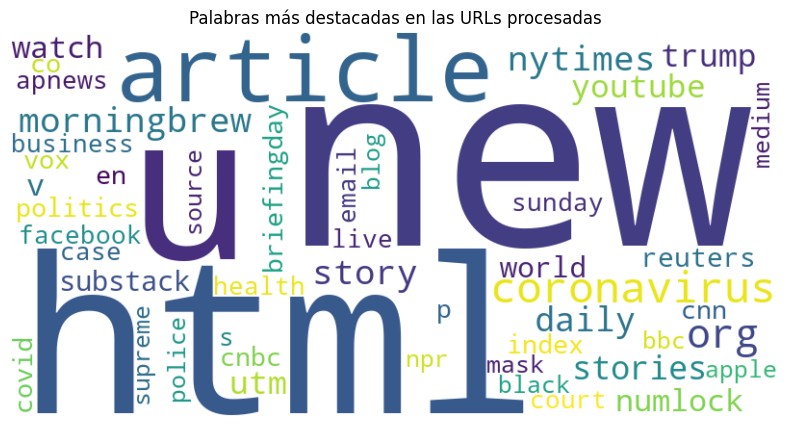

In [56]:

# 1. Unir todos los textos de la columna 'url_prepro' en un solo bloque
# Eliminamos posibles valores nulos con dropna() para evitar errores
todo_el_texto = " ".join(df['url_prepro'].dropna())

# 2. Generar la nube de palabras global
wordcloud = WordCloud(
    background_color="white", 
    max_words=50, 
    contour_color="steelblue", 
    collocations=False, # Evita que se repitan palabras combinadas
    width=800, 
    height=400
).generate(todo_el_texto)

# 3. Mostrar la imagen final
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Palabras más destacadas en las URLs procesadas")
plt.axis("off")
plt.show()

In [57]:
X_train, X_test, y_train, y_test = train_test_split(df.url_prepro, df.is_spam, test_size=0.2, random_state=42)

In [58]:
# Crear una instancia del LabelEncoder
label_encoder = LabelEncoder()

# Ajustar y transformar la columna 'is_spam' con el LabelEncoder
y_train_label = label_encoder.fit_transform(y_train)
y_test_label = label_encoder.transform(y_test)

In [59]:
# Convertimos las palabras a números
vectorizer = TfidfVectorizer(min_df=0.001)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [60]:
X_train_vec.toarray().shape

(1892, 1871)

# Modelacion SVC

In [ ]:
from sklearn.svm import SVC


model = SVC(kernel="linear", C=1.0, class_weight='balanced')
model.fit(X_train_vec, y_train_label)

y_pred = model.predict(X_test_vec)
print(classification_report(y_test_label, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

              precision    recall  f1-score   support

       False       0.96      0.89      0.92       420
        True       0.44      0.70      0.54        53

    accuracy                           0.87       473
   macro avg       0.70      0.79      0.73       473
weighted avg       0.90      0.87      0.88       473



## Hiperparametros

In [ ]:

# Definir el espacio de búsqueda
param_dist = {
    'C': np.logspace(-3, 2, 6),           # De 0.001 a 100
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['linear', 'rbf'],
    'class_weight': ['balanced', None]    # Clave para tu problema de spam
}

random_search = RandomizedSearchCV(
    SVC(), 
    param_distributions=param_dist, 
    n_iter=10, 
    scoring='f1_macro', # F1-macro da el mismo peso a Spam y No-Spam
    cv=5, 
    verbose=1, 
    random_state=42
)

random_search.fit(X_train_vec, y_train_label)
print(f"Mejores parámetros iniciales: {random_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros iniciales: {'kernel': 'linear', 'gamma': 1, 'class_weight': None, 'C': np.float64(100.0)}


In [ ]:
# 1. Definimos la rejilla basándonos en los resultados previos

param_grid = {
    'C': [50, 75, 100, 150, 200], # Exploramos valores cerca de 100
    'kernel': ['linear'],
    'class_weight': [None, 'balanced'] # Volvemos a comparar si balancear ayuda al Recall
}

# 2. Configuramos el GridSearchCV
# Usamos f1_macro para proteger la clase minoritaria (Spam)
grid_search = GridSearchCV(
    SVC(), 
    param_grid, 
    scoring='f1_macro', 
    cv=5, 
    verbose=2,
    n_jobs=-1 # Usa todos los procesadores para ir más rápido
)

# 3. Entrenamos
print("Iniciando refinamiento con GridSearchCV...")
grid_search.fit(X_train_vec, y_train_label)

# 4. Resultados
print(f"\nMejores parámetros finales: {grid_search.best_params_}")

# 5. Evaluación final
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_vec)

# Mostramos el reporte final
target_names = [str(c) for c in label_encoder.classes_]
print("\nReporte de Clasificación Final:")
print(classification_report(y_test_label, y_pred_final, target_names=target_names))

Iniciando refinamiento con GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros finales: {'C': 75, 'class_weight': None, 'kernel': 'linear'}

Reporte de Clasificación Final:
              precision    recall  f1-score   support

       False       0.95      0.96      0.95       420
        True       0.64      0.60      0.62        53

    accuracy                           0.92       473
   macro avg       0.80      0.78      0.79       473
weighted avg       0.92      0.92      0.92       473



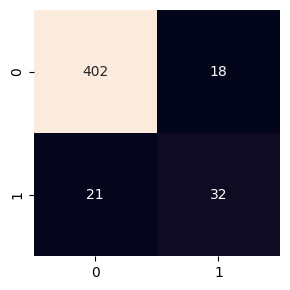

In [73]:
matriz_cm = confusion_matrix(y_test_label, y_pred_final)
cm_df = pd.DataFrame(matriz_cm)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
plt.tight_layout()
plt.show() 

## Analisis
- Rendimiento General: El modelo es muy sólido para identificar URLs legítimas (96% de acierto), pero aún tiene dificultades con el Spam debido a que hay pocos ejemplos para entrenar.

- Capacidad de Detección (Recall): Lograste capturar el 60% del Spam real (32 de 53 casos). Es una mejora enorme frente al modelo inicial, aunque todavía se le escapan 21 URLs maliciosas.

- Fiabilidad (Precisión): Cuando el modelo marca algo como Spam, tiene un 64% de probabilidad de tener razón. El resto son "falsas alarmas" de URLs seguras.

- Balance Final: El modelo es eficiente pero conservador. Prefiere dejar pasar algunos casos dudosos antes que bloquear por error demasiadas URLs normale

# Guardamos modelo

In [74]:
joblib.dump(best_model, 'modelo_url_SVC.pkl')

['modelo_url_SVC.pkl']